<a href="https://colab.research.google.com/github/ailavajuthy/Handwritten-Digit-Classification/blob/main/HandWritten_Digit_Classifier_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import matplotlib.pylab as plt
import numpy as np

In [ ]:
def show_data(data_sample):
    plt.imshow(data_sample[0].numpy().reshape(28, 28), cmap='gray')
    plt.title('y = ' + str(data_sample[1]))

In [ ]:
#Downloaded MNIST training data and display
train_dataset=dsets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
print("Print the training dataset: \n", train_dataset)

100%|██████████| 9.91M/9.91M [00:00<00:00, 64.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.77MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.71MB/s]

Print the training dataset: 
 Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()


In [ ]:
#Downloaded MNIST validation data and display
validation_dataset = dsets.MNIST(root='./data', download=True, transform=transforms.ToTensor())
print("Print the validation dataset:\n ", validation_dataset)

Print the validation dataset:
  Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()


Image and label


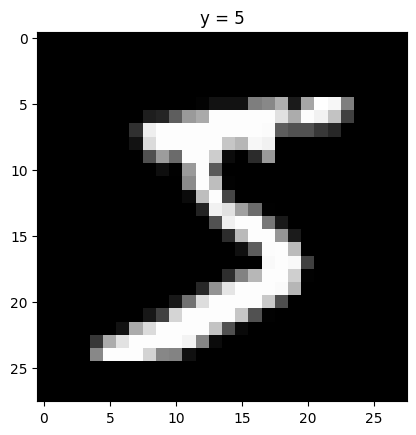

In [ ]:
#Display the first image and its corresponding label(the number the image shows)

print("Image and label")
show_data(train_dataset[0])

In [ ]:
print("Just label: ", train_dataset[0][1])

Just label:  5


In [ ]:
class Logistic_Regression(nn.Module):
  def __init__(self, input_size, output_size):
    super(Logistic_Regression, self).__init__()
    #creates a layer that takes in x inputs and produces y outputs
    self.linear=nn.Linear(input_size, output_size)
  def forward(self, x):
    #we don't apply the sigmoid function as this isn't a binary classification problem
    #the output is the raw score of the strength of the image being each of the 10 digits
    #so the output is a vector of raw scores
    #note, this isn't probability. this is alter found using the softmax function
    #raw scores are not normalized between 0 and 1
    #later on, the softmax function will take the raw scores vector snd decide which digit is most likely
    #cross entropy loss requires this raw scores
    z=self.linear(x)
    return z

In [ ]:
train_dataset[0][0].shape

torch.Size([1, 28, 28])

In [ ]:
input_dim=28*28
output_dim=10

In [ ]:
#the input is the 784 pixels and the output size is 10 digits
model=Logistic_Regression(input_dim, output_dim)
print("Print the model:\n ", model)

Print the model:
  Logistic_Regression(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)


In [ ]:
#the weights and biases are updated during training and remain constant afterward
#ie the same weights and biases are used to predict the digit after training is over
#they don't vary from test image to test image
print('W: ',list(model.parameters())[0].size())
print('b: ',list(model.parameters())[1].size())

W:  torch.Size([10, 784])
b:  torch.Size([10])


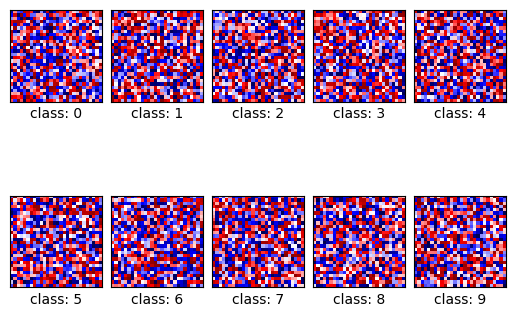

In [ ]:
PlotParameters(model)

In [ ]:
#flatten the 28*28 image into a 1,784 vector
X=train_dataset[0][0]
print(X.shape)
X=X.view(-1,28*28)
print(X.shape)
model(X)

torch.Size([1, 28, 28])
torch.Size([1, 784])


tensor([[-0.1942, -0.0246,  0.0563, -0.0267,  0.1263,  0.1168, -0.0968, -0.3805,
         -0.2771,  0.2005]], grad_fn=<AddmmBackward0>)

In [ ]:
learning_rate=0.1
#optimizers updates the model parameters using the learning rate
#the model parameters are weight and bias
#this gradually improves accuracy of predictions
optimizer=torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
#criterion measures the loss between the prediction and the actual label
criterion=nn.CrossEntropyLoss()
#create a training dataloader and divides training data into batches
train_loader=torch.utils.data.DataLoader(dataset=train_dataset, batch_size=100)
#create a training dataloader and divides training data into batches
validation_loader=torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=5000)

Output:  tensor([[-0.1942, -0.0246,  0.0563, -0.0267,  0.1263,  0.1168, -0.0968, -0.3805,
         -0.2771,  0.2005]], grad_fn=<AddmmBackward0>)
Actual: tensor([5])


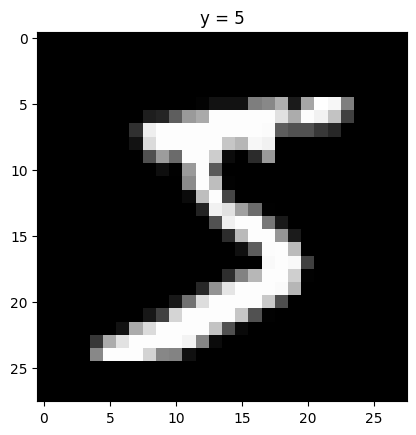

In [ ]:
#vector of raw scores of each digit
model_output=model(X)
actual = torch.tensor([train_dataset[0][1]])

show_data(train_dataset[0])
print("Output: ", model_output)
print("Actual:", actual)

In [ ]:
#calculate loss between prediction and actual
criterion(model_output, actual)

tensor(2.1512, grad_fn=<NllLossBackward0>)

In [ ]:
#use softmax to convert raw scores to probabilities as probabilities are easier to interpret
#this allows you to easily pick the most likely class by choosing the one with the highest probability
softmax=nn.Softmax(dim=1)
probability=softmax(model_output)
print(probability)

tensor([[0.0852, 0.1010, 0.1095, 0.1008, 0.1174, 0.1163, 0.0940, 0.0708, 0.0785,
         0.1265]], grad_fn=<SoftmaxBackward0>)


In [ ]:
#penalizes wrong predictions more strongly
-1*torch.log(probability[0][actual])

tensor([2.1512], grad_fn=<MulBackward0>)

In [ ]:
#number of times we train the entire dataset
epochs=100
loss_list=[]
accuracy_list=[]
test=len(validation_dataset)

def train_model(epochs):
  for epoch in range(epochs):
    for x,y in train_loader:
      #Resets calculated gradient value because it would otherwise accumulate
      optimizer.zero_grad()
      #converts x to a [1,784] tensor before passing it through the model
      #x is a batch of images
      z=model(x.view(-1,28*28))
      #calcualte loss between output and actual
      loss=criterion(z,y)#this is height of where we're standing on the hill based on current weight and biases
      #calculate gradient value wrt to weight and bias
      loss.backward()#find the slope of where we're standing on the hill right now
      #updates weights and baises based on the gradient value
      optimizer.step()#moves down the hill according to the gradient value. moves in opposite direction
    #check how well the model performs with validation data
    #keep track of correct outputs
    correct=0
    for a, b in validation_loader:
      z=model(a.view(-1,28*28))
      #z.data accesses raw tensor data without gradient tracking
      #torch.max computes the max value and its index
      #this returns the max value, which we ignore using _
      #then yhat is the class label (digit from 0-9)
      _,yhat=torch.max(z.data, 1)
      #increment correct count if yhat matches the actual label
      correct+=(yhat==b).sum().item()
      #output accuracy
      accuracy=correct/test
      loss_list.append(loss.data)
      accuracy_list.append(accuracy)
train_model(epochs)

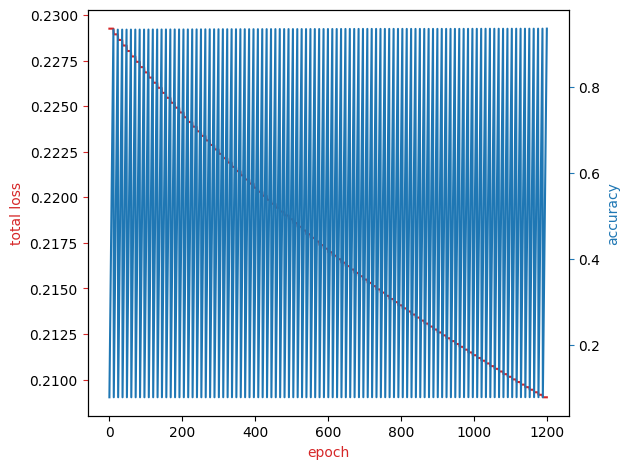

In [ ]:
fig, ax1=plt.subplots()
color='tab:red'
ax1.plot(loss_list, color=color)
ax1.set_xlabel('epoch',color=color)
ax1.set_ylabel('total loss',color=color)
ax1.tick_params(axis='y', color=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('accuracy', color=color)
ax2.plot( accuracy_list, color=color)
ax2.tick_params(axis='y', color=color)
fig.tight_layout()

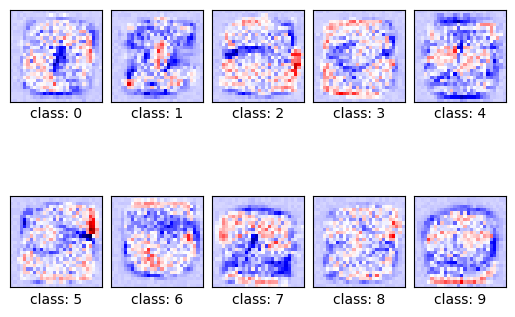

In [ ]:
PlotParameters(model)

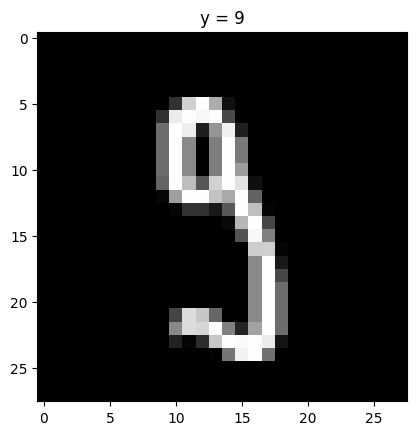

yhat: tensor([5])
probability of class  0.7029355764389038


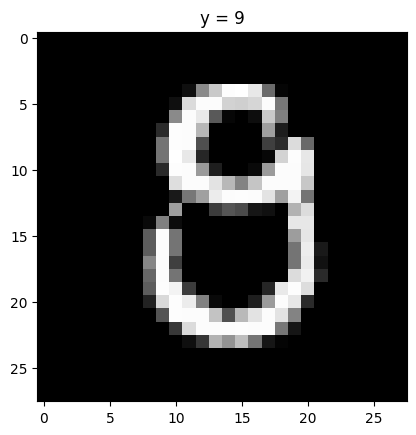

yhat: tensor([8])
probability of class  0.6128306984901428


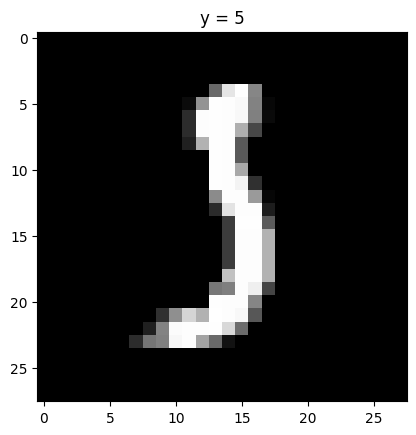

yhat: tensor([3])
probability of class  0.8157908320426941


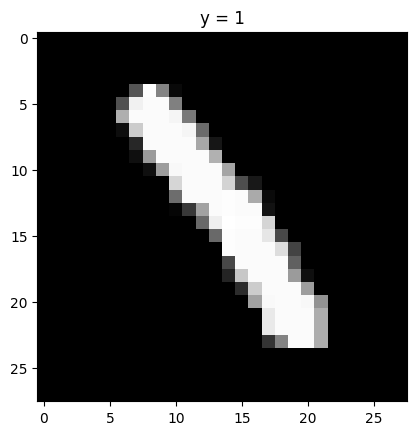

yhat: tensor([3])
probability of class  0.5056580901145935


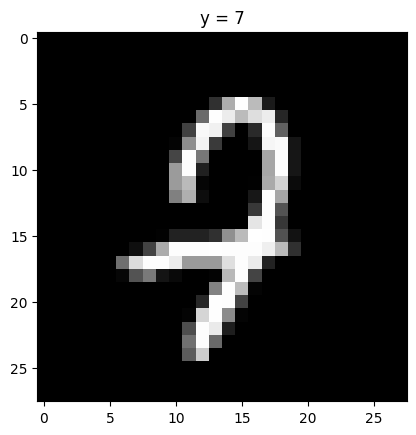

yhat: tensor([9])
probability of class  0.6473560333251953


In [ ]:
# Plot the misclassified samples
Softmax_fn=nn.Softmax(dim=-1)
count = 0
for x, y in validation_dataset:
    z = model(x.reshape(-1, 28 * 28))
    _, yhat = torch.max(z, 1)
    if yhat != y:
        show_data((x, y))
        plt.show()
        print("yhat:", yhat)
        print("probability of class ", torch.max(Softmax_fn(z)).item())
        count += 1
    if count >= 5:
        break

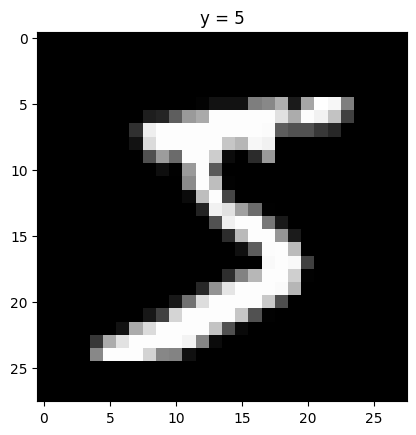

yhat: tensor([5])
probability of class  0.8445946574211121


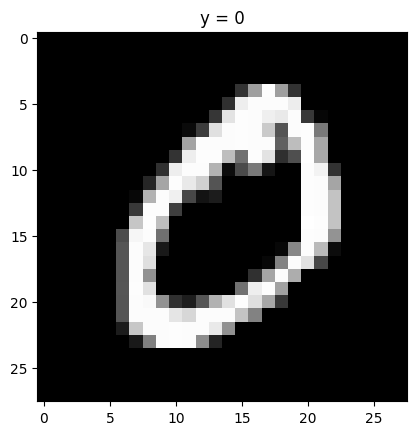

yhat: tensor([0])
probability of class  0.9999839067459106


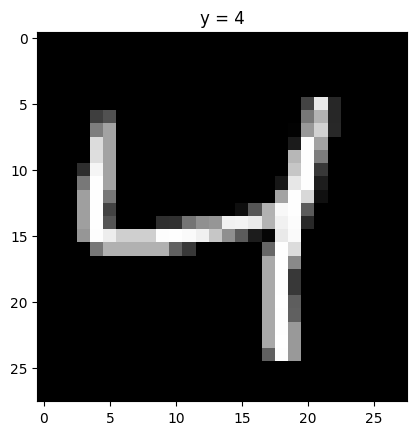

yhat: tensor([4])
probability of class  0.7795371413230896


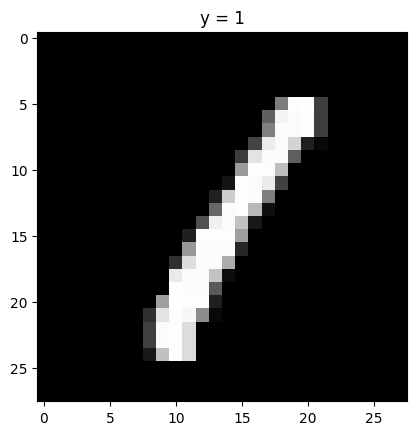

yhat: tensor([1])
probability of class  0.9790710210800171


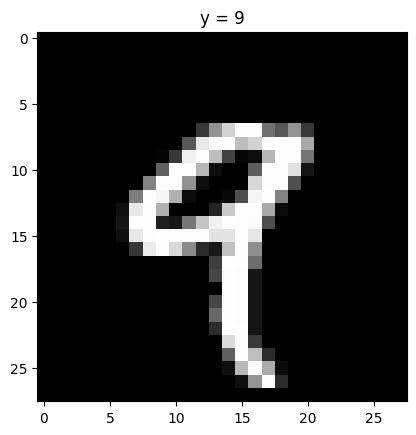

yhat: tensor([9])
probability of class  0.9665998816490173


In [ ]:
Softmax_fn=nn.Softmax(dim=-1)
count = 0
for x, y in validation_dataset:
    z = model(x.reshape(-1, 28 * 28))
    _, yhat = torch.max(z, 1)
    if yhat == y:
        show_data((x, y))
        plt.show()
        print("yhat:", yhat)
        print("probability of class ", torch.max(Softmax_fn(z)).item())
        count += 1
    if count >= 5:
        break

In [ ]:
accuracy_list[-1]

0.9355333333333333